
# **PEC 1: Data Mining and Dimensionality Reduction Methods**

Throughout this practical session, we will see how to apply different techniques that we have seen in class, such as EDA, Data Wrangling, or techniques to reduce the dimensionality of the dataset. To do this, we will carry out the following steps:

1.  Loading a dataset
2.  Data analysis

    2.1 Basic statistical analysis
    
    2.2 Exploratory data analysis

For this, we will need the following libraries:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn import preprocessing
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.linear_model import Lasso, lasso_path
import math

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
seed = 100

%matplotlib inline

# **1. Loading the dataset**

First, you must load the "Boston house prices" dataset, which contains the value of houses in different areas of Boston depending on multiple factors.

For the exercises in this example activity, we will use "MEDV" as the response variable: the median value of houses in an area of Boston (in k$).


**FIRST STEP: WHAT TYPE OF DATA SOURCE DO WE HAVE?**


### **Exercise:**

Load the "boston house-prices dataset" and show:

*   the number and name of the attributes (variables that could be used to predict the "MEDV" response)
*   the number of rows in the dataset

**Hint:** If you use sklearn (`sklearn.datasets.load_boston`), explore the different 'keys' of the obtained object.

**Hint:** It may be useful to pass the data (attributes + response) to a pandas dataframe.




## Attribute Information:

1.  CRIM     per capita crime rate by town
2.  ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
3.  INDUS    proportion of non-retail business acres per town
4.  CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
5.  NOX      nitric oxides concentration (parts per 10 million)
6.  RM       average number of rooms per dwelling
7.  AGE      proportion of owner-occupied units built prior to 1940
8.  DIS      weighted distances to five Boston employment centres
9.  RAD      index of accessibility to radial highways
10. TAX      full-value property-tax rate per $10,000
11. PTRATIO  pupil-teacher ratio by town

12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13. LSTAT    % lower status of the population
14. MEDV     Median value of owner-occupied homes in $1000's




**SECOND STEP: LET'S QUICKLY EXPLORE WHAT WE HAVE**

In [2]:
# HELP - SUGGESTION. INSTALL PACKAGE TO SEE WHAT'S THERE; USING, FOR EXAMPLE, THE PLOT FUNCTION OF THE DATAPREP.EDA MODULE OF THE DATAPREP PACKAGE # We put the ! to install a package
from dataprep.eda import plot # With from _____ import we install the X method of the Y package

# HELP - SUGGESTION. IN THE FIRST STEP, WHEN READING THE HousingData.csv DATASET, WE ASSIGNED IT TO THE DATAFRAME VARIABLE "boston"

boston = pd.read_csv('HousingData.csv') # We read the dataset and assign it to the variable boston
plot(boston).show_browser() # With plot from the DataPrep library we can get a report of our dataset

  0%|          | 0/908 [00:00<?, ?it/s]

In [3]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [4]:
df = boston

In [5]:
df.shape

(506, 14)

# **Basic statistical analysis**

### **Exercise:**

Perform a basic statistical analysis:


*   **Categorical variables:**
    *   Calculate the frequency
    *   Make a bar graph
*   **Numerical variables:**
    *   Calculate basic descriptive statistics: mean, median, standard deviation, ...
    *   Make a histogram of the INDUS, AGE and MEDV variables

**Hint:** You can use the 'pandas' library and its 'describe' and 'value_counts' functions, as well as the 'bar' and 'hist' functions of matplotlib.

### Check for null data

In [6]:
for column in df.columns:
    print(f"Column: {column}, Data type: {df[column].dtype}, Number of null values: {df[column].isna().sum()}")

Column: CRIM, Data type: float64, Number of null values: 20
Column: ZN, Data type: float64, Number of null values: 20
Column: INDUS, Data type: float64, Number of null values: 20
Column: CHAS, Data type: float64, Number of null values: 20
Column: NOX, Data type: float64, Number of null values: 0
Column: RM, Data type: float64, Number of null values: 0
Column: AGE, Data type: float64, Number of null values: 20
Column: DIS, Data type: float64, Number of null values: 0
Column: RAD, Data type: int64, Number of null values: 0
Column: TAX, Data type: int64, Number of null values: 0
Column: PTRATIO, Data type: float64, Number of null values: 0
Column: B, Data type: float64, Number of null values: 0
Column: LSTAT, Data type: float64, Number of null values: 20
Column: MEDV, Data type: float64, Number of null values: 0


In [7]:
df['CRIM'].fillna(df['CRIM'].mean(), inplace=True)
df['ZN'].fillna(df['ZN'].mean(), inplace=True)
df['INDUS'].fillna(df['INDUS'].mean(), inplace=True)
df = df.dropna(subset=['CHAS'])
df['AGE'].fillna(df['AGE'].mean(), inplace=True)
df['LSTAT'].fillna(df['LSTAT'].mean(), inplace=True)

C:\Users\Eva Sánchez\AppData\Local\Temp\ipykernel_19076\3744441218.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AGE'].fillna(df['AGE'].mean(), inplace=True)
C:\Users\Eva Sánchez\AppData\Local\Temp\ipykernel_19076\3744441218.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LSTAT'].fillna(df['LSTAT'].mean(), inplace=True)


In [8]:
for column in df.columns:
    print(f"Column: {column}, Data type: {df[column].dtype}, Number of null values: {df[column].isna().sum()}")

Column: CRIM, Data type: float64, Number of null values: 0
Column: ZN, Data type: float64, Number of null values: 0
Column: INDUS, Data type: float64, Number of null values: 0
Column: CHAS, Data type: float64, Number of null values: 0
Column: NOX, Data type: float64, Number of null values: 0
Column: RM, Data type: float64, Number of null values: 0
Column: AGE, Data type: float64, Number of null values: 0
Column: DIS, Data type: float64, Number of null values: 0
Column: RAD, Data type: int64, Number of null values: 0
Column: TAX, Data type: int64, Number of null values: 0
Column: PTRATIO, Data type: float64, Number of null values: 0
Column: B, Data type: float64, Number of null values: 0
Column: LSTAT, Data type: float64, Number of null values: 0
Column: MEDV, Data type: float64, Number of null values: 0


### Categorical variables

0.0    452
1.0     34
Name: CHAS, dtype: int64


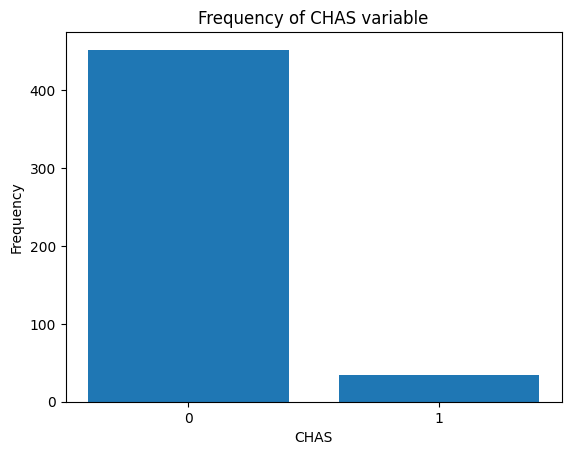

In [9]:
# Frecuency of the CHAS variable
counts = df['CHAS'].value_counts()

# x_axis and y_axis for the bar plot
x_axis = counts.index
y_axis = df['CHAS'].value_counts()

# Plotting the frecuency of the CHAS variable
plt.bar(x_axis, y_axis)
plt.xlabel('CHAS')
plt.ylabel('Frequency')
plt.title('Frequency of CHAS variable')
plt.xticks(x_axis)

print(counts)

### Numerical variables

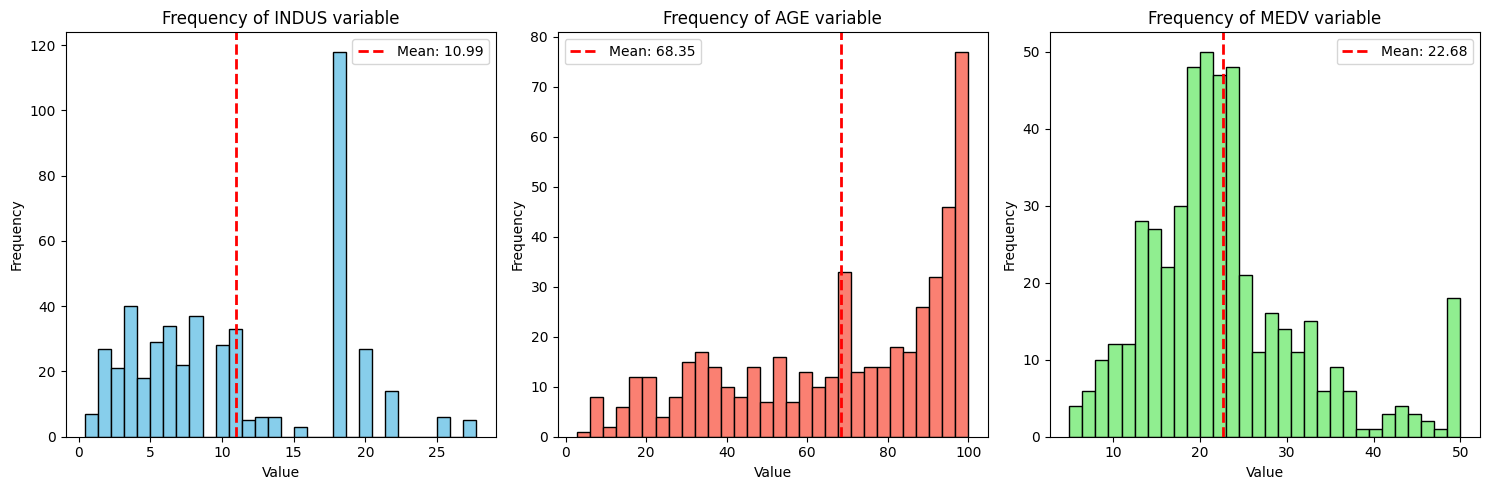

Mean of INDUS: 10.99
Mean of AGE: 68.35
Mean of MEDV: 22.68


In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# --- Graph 1 (Column 0) ---
axs[0].hist(df['INDUS'], bins=30, color='skyblue', edgecolor='black')
axs[0].set_title('Frequency of INDUS variable')
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Frequency")

# Add mean line
mean_indus = df['INDUS'].mean()
axs[0].axvline(mean_indus, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_indus:.2f}')
axs[0].legend()

# --- Graph 2 (Column 1) ---
axs[1].hist(df['AGE'], bins=30, color='salmon', edgecolor='black')
axs[1].set_title('Frequency of AGE variable')
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Frequency")

# Add mean line
mean_age = df['AGE'].mean()
axs[1].axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.2f}')
axs[1].legend()

# --- Graph 3 (Column 2) ---
axs[2].hist(df['MEDV'], bins=30, color='lightgreen', edgecolor='black')
axs[2].set_title('Frequency of MEDV variable')
axs[2].set_xlabel("Value")
axs[2].set_ylabel("Frequency")

# Add mean line
mean_medv = df['MEDV'].mean()
axs[2].axvline(mean_medv, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_medv:.2f}')
axs[2].legend()

plt.tight_layout()
plt.show()

print(f"Mean of INDUS: {mean_indus:.2f}")
print(f"Mean of AGE: {mean_age:.2f}")
print(f"Mean of MEDV: {mean_medv:.2f}")

In [11]:
column = []
mean = []
median = []
standard_deviation = []
mode = []


for column in df.columns:
    mean.append(df[column].mean())
    median.append(df[column].median())
    standard_deviation.append(df[column].std())
    mode.append(df[column].mode()[0])

statistics = pd.DataFrame({'Column': df.columns, 'Mean': mean, 'Median': median, 'Standard_Deviation': standard_deviation, 'Mode': mode})
statistics

,Column,Mean,Median,Standard_Deviation,Mode
0,CRIM,3.562090,0.289575,8.634572,3.611874
1,ZN,11.350285,0.000000,23.073829,0.000000
2,INDUS,10.989827,9.795000,6.734251,18.100000
3,CHAS,0.069959,0.000000,0.255340,0.000000
4,NOX,0.553699,0.538000,0.115390,0.538000
5,RM,6.296835,6.209000,0.699175,5.713000
6,AGE,68.353863,74.350000,27.504857,100.000000
7,DIS,3.788976,3.207450,2.096304,3.495200
8,RAD,9.395062,5.000000,8.626756,24.000000
9,TAX,405.485597,330.000000,167.604833,666.000000


# **Analysis:**

Comment on the results.

1º Firstly we can observe that there are many more blocks that do not contact the shoreline of the river (452(0)>34(1)). Logically, this is due to there being much less surface area to build next to the river than building somewhere else.

2º With the bar charts of INDUS, AGE AND MEDV, we can compare how the Industry density and Age of the housing affects the median value of the housing. Lets compare INDUS to MEDV and see if we can deduce any trends. As we can see they have an inverse negative relation, meaning that as INDUS frequencies are greater the MEDV frequency (or values) decrease. This makes sense, as we know living next to big industries facilities may imply having to deal with loud noises, pollution or living close to residues and waste. To be sure of our deduction we can calculate the correlation index, as seen in the cell below.

Now we will compare AGE and MEDV. We could presume at first that the older the house the lower the MEDV value due to it needing to be renovated or being part of a suburb that hasn't been renovated, predicting yet again an inverse negative relation. This trend we just mentioned prevails until we see an spike in MEDV when we get into the oldest houses. This could make sense since some houses have an important historical value that increases the price.


,Variable,Correlation with MEDV,R^2 with MEDV
0,INDUS,-0.476846,0.227382
1,AGE,-0.376188,0.141517


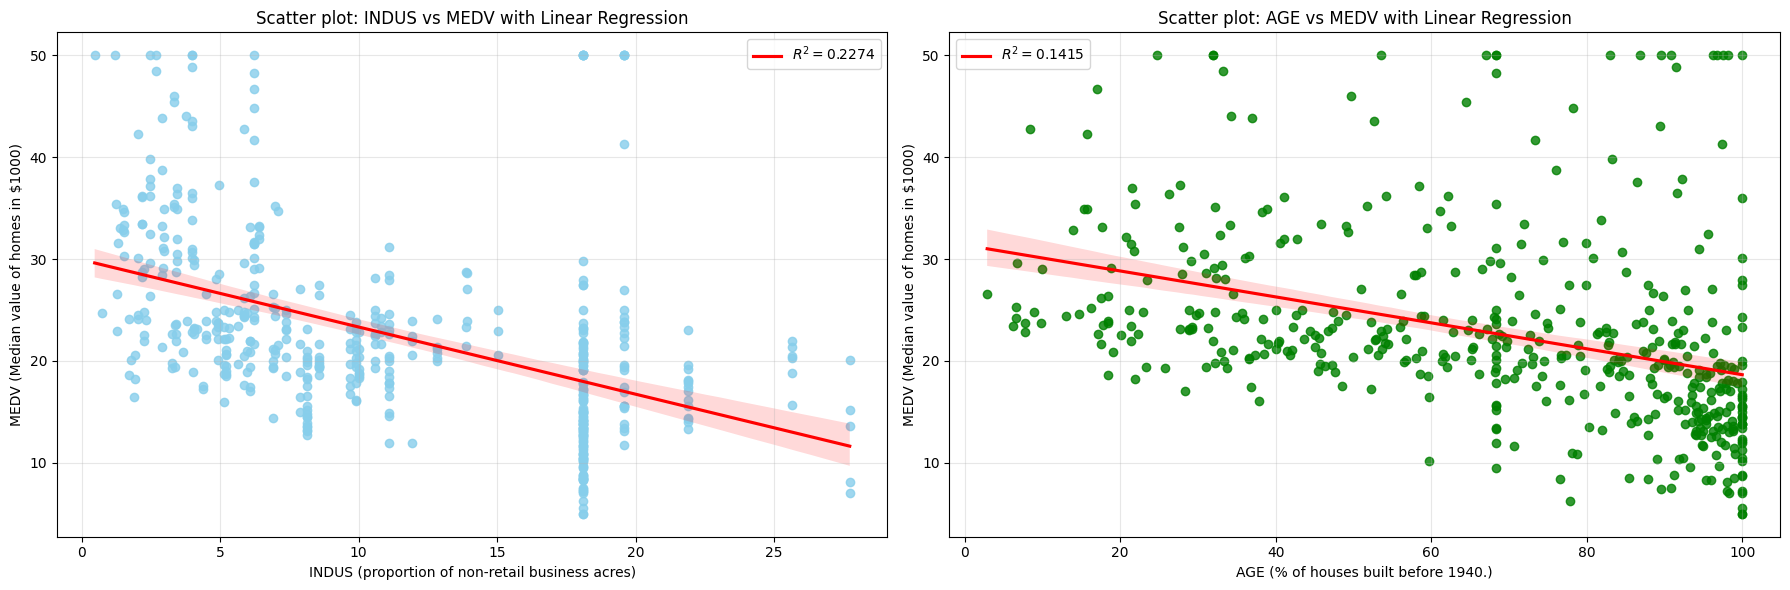

In [12]:
# Also print the correlation coefficient
correlation_indus_medv = df['INDUS'].corr(df['MEDV'])

# Also print the correlation coefficient
correlation_age_medv = df['AGE'].corr(df['MEDV'])

r2_indus = correlation_indus_medv**2
r2_age = correlation_age_medv**2

df_correlation = pd.DataFrame({'Variable': ['INDUS', 'AGE'],'Correlation with MEDV': [correlation_indus_medv, correlation_age_medv],'R^2 with MEDV': [r2_indus, r2_age]})

display(df_correlation)

# Create subplot of 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter plot: INDUS vs MEDV with linear regression line (left)
sns.regplot(x='INDUS', y='MEDV', data=df, scatter_kws={'color': 'skyblue'}, 
            line_kws={'color':'red', 'label': f'$R^2 = {r2_indus:.4f}$'}, ax=axes[0])
axes[0].set_xlabel('INDUS (proportion of non-retail business acres)')
axes[0].set_ylabel('MEDV (Median value of homes in $1000)')
axes[0].set_title('Scatter plot: INDUS vs MEDV with Linear Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot: AGE vs MEDV with linear regression line (right)
sns.regplot(x='AGE', y='MEDV', data=df, scatter_kws={'color': 'green'}, 
            line_kws={'color':'red', 'label': f'$R^2 = {r2_age:.4f}$'}, ax=axes[1])
axes[1].set_xlabel('AGE (% of houses built before 1940.)')
axes[1].set_ylabel('MEDV (Median value of homes in $1000)')
axes[1].set_title('Scatter plot: AGE vs MEDV with Linear Regression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Exploratory data analysis**

In this exercise, we will explore the relationship of the attributes with the response variable, through graphs and analyzing the correlations of the numerical attributes.

In [13]:
response = "MEDV"
cat_feat = "CHAS"
num_feats = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
print('Response ("target"):', response)
print("Categorical attribute:", cat_feat)
print("Numerical attributes:", num_feats)

Response ("target"): MEDV
Categorical attribute: CHAS
Numerical attributes: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


### **Exercise:**

Make a graph of the histogram of values of the response variable, separated by the possible values (classes) of the categorical attribute. To better compare the MEDV values for the different CHAS classes, the histograms in the graph must be superimposed. Add a legend to know which class each histogram corresponds to. The purpose is to observe how the value of the MEDV response is distributed according to the value of the CHAS class, to be able to visually and quickly identify if this categorical attribute is related to different values of the response.

**Hint:** You can use the "hist" function of the "matplotlib" library, as well as its "alpha" parameter so that the superimposed histograms are appreciated.

**Hint:** To better compare the histograms, consider representing the probability density instead of the number of entries per bin. In this way, the scale of the histograms will be the same for each class and it will be easy to compare. You can use the "density" parameter of the same "hist" function.

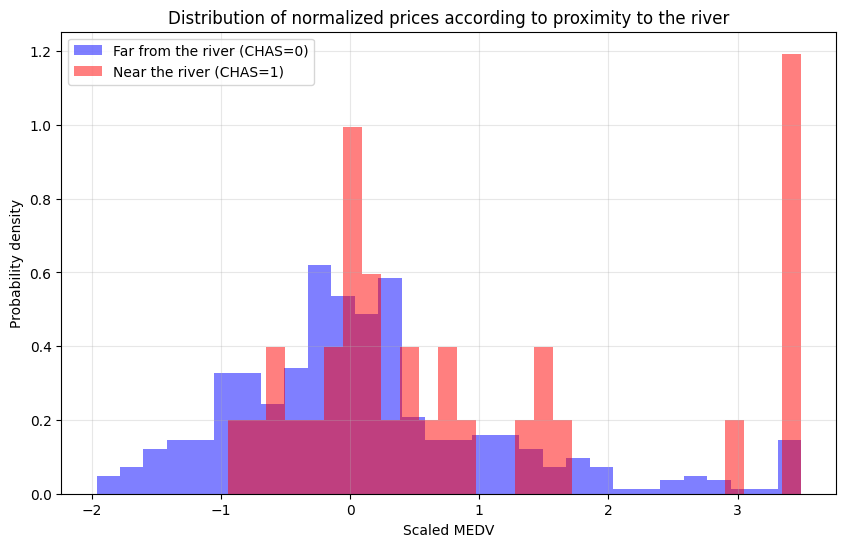

In [14]:
# Create a copy of the DataFrame to avoid modifiying the original one
df = df.copy()

# Normalize the MEDV variable using RobustScaler
scaler = RobustScaler()
df['MEDV_normalized'] = scaler.fit_transform(df[['MEDV']])

# Separate normalized data by CHAS class
medv_norm_chas0 = df[df['CHAS'] == 0]['MEDV_normalized']
medv_norm_chas1 = df[df['CHAS'] == 1]['MEDV_normalized']

# Create the plot
plt.figure(figsize=(10, 6))

# Histograms
counts0, bins0, patches0 = plt.hist(medv_norm_chas0, bins=30, alpha=0.5, color='blue', density=True, label='Far from the river (CHAS=0)')
counts1, bins1, patches1 = plt.hist(medv_norm_chas1, bins=30, alpha=0.5, color='red', density=True, label='Near the river (CHAS=1)')

# Add mean lines
plt.xlabel('Scaled MEDV')
plt.ylabel('Probability density')
plt.title('Distribution of normalized prices according to proximity to the river')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Analysis:**

Looking at the histograms, does it seem that the CHAS attribute will have any weight when predicting the median house price, MEDV? Why?

It is a relevant attribute that will definitely affect MEDV, although it might not be the most influential one. Deducing from the graph, we can determine that both distributions share a similar range, but houses closer to the river have a distribution that is shifted to the right. As expected, there are generally more expensive houses next to the river, which is obvious when observing the frequency of higher-priced homes in that category. Houses next to rivers are more expensive primarily due to the basic economic principle of supply and demand: desirable waterfront land is a limited resource. This scarcity drives up prices, which is compounded by the numerous lifestyle benefits, aesthetic appeal, and strong investment potential associated with riverside living.


### **Exercise:**

Repeat the previous histograms, adding a vertical line indicating the mean of each of the histograms. Paint the lines in the same color as the histogram so that it is clear which one they refer to. Add to the legend the CHAS class and the values of the mean and the standard deviation in question. The purpose is to numerically verify the differences identified previously visually.

**Hint:** You can use "axvline", from matplotlib axis, for the vertical lines.

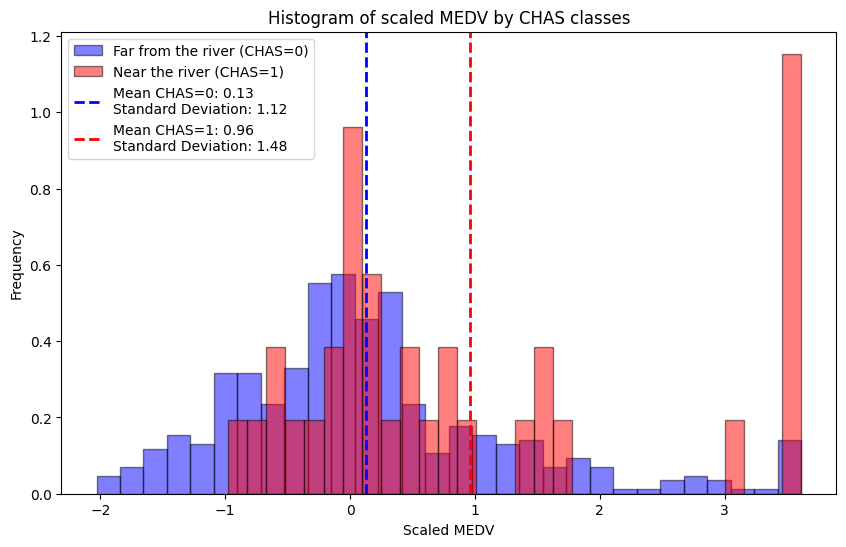

In [15]:
scaler = RobustScaler()

boston['MEDV_scaled'] = scaler.fit_transform(boston[['MEDV']])

plt.figure(figsize=(10, 6))

# Filter data for each CHAS class - keep ALL columns, not just MEDV_scaled
chas_0 = boston[boston['CHAS'] == 0]
chas_1 = boston[boston['CHAS'] == 1]

# Create histograms using MEDV_scaled
plt.hist(chas_0['MEDV_scaled'],bins=30, alpha=0.5, color='blue', density=True, label='Far from the river (CHAS=0)', edgecolor='black')
plt.hist(chas_1['MEDV_scaled'], bins=30, alpha=0.5, color='red', density=True, label='Near the river (CHAS=1)', edgecolor='black')

# Add vertical lines showing the mean of MEDV_scaled for each class
plt.axvline(chas_0['MEDV_scaled'].mean(), color='blue', linestyle='dashed', linewidth=2, 
            label=f'Mean CHAS=0: {chas_0["MEDV_scaled"].mean():.2f}\nStandard Deviation: {chas_0["MEDV_scaled"].std():.2f}')  # value = indicates format specification / .2 = shows exactly 2 decimals / f = indicates float
plt.axvline(chas_1['MEDV_scaled'].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Mean CHAS=1: {chas_1["MEDV_scaled"].mean():.2f}\nStandard Deviation: {chas_1["MEDV_scaled"].std():.2f}')

# Add labels and legend
plt.xlabel('Scaled MEDV')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of scaled MEDV by CHAS classes')
plt.show()

### Confirmation 

As we discussed before, now we can evidently see that there's a higher average concentration of houses near the river that are more expensive, this is illustrated by the red dotted line in the graph.


### **Exercise:**

Identify the two attributes that have the strongest correlation with the response and the 2 with the weakest correlation (correlation coefficient greater or less in absolute value). To observe and analyze the correlations graphically, represent, for each of the 4 identified attributes, a scatter plot with the attribute on the x-axis and the response on the y-axis. In addition, in each graph, add the representation of a linear regression that fits the points.

Hint: You can use the "regplot" function from the 'seaborn' library.

### Checking for Outliers

C:\Users\Eva Sánchez\AppData\Local\Temp\ipykernel_19076\141982549.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(feature_names)))


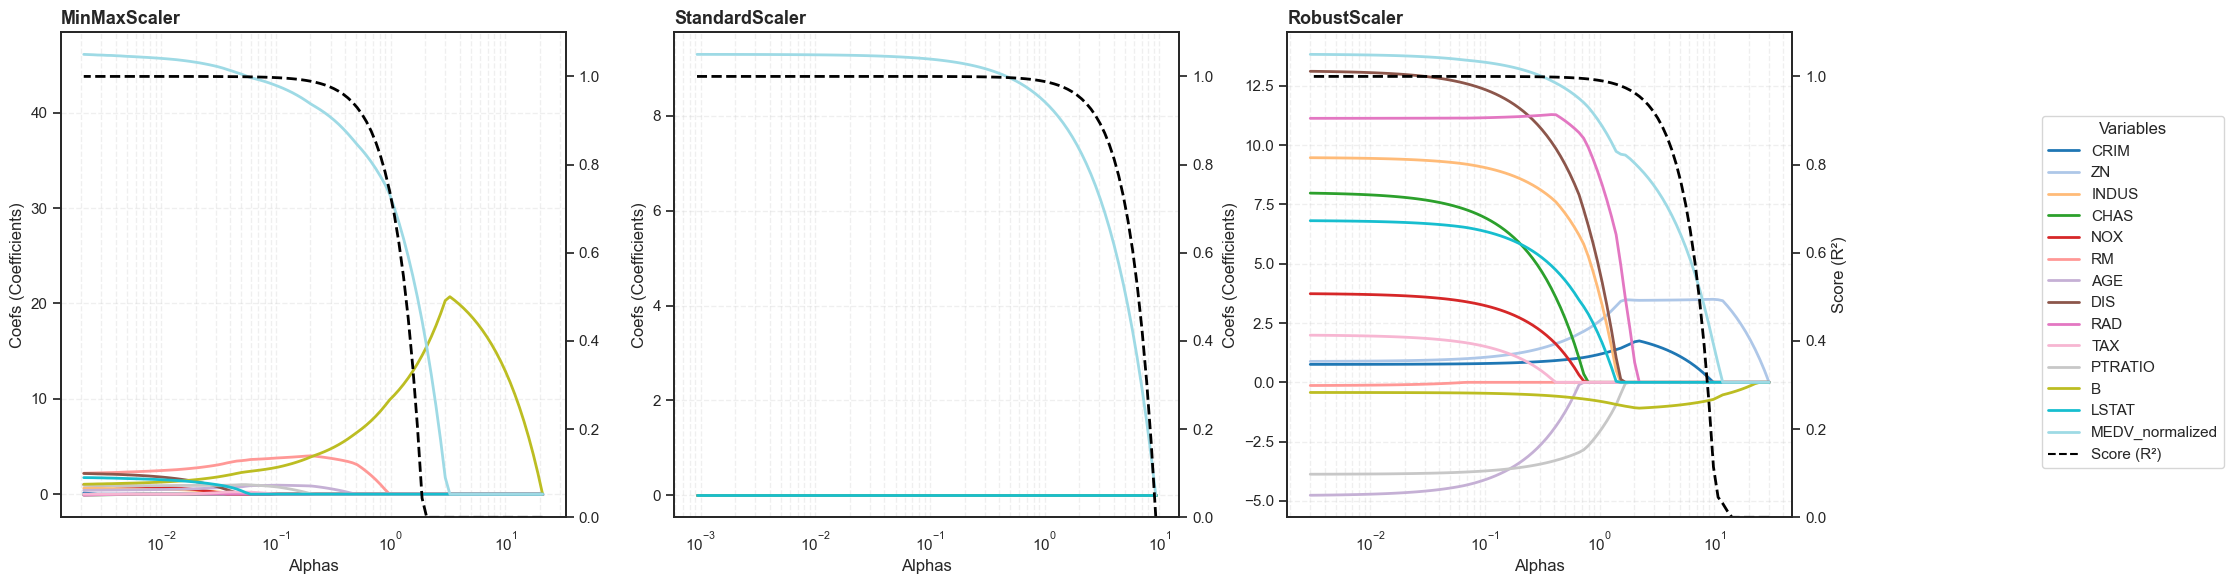

In [26]:
target_column = 'MEDV' 

# 1. Separate features (X) and target (y) from the DataFrame
X = df.drop(columns=[target_column])
y = df[target_column]
feature_names = X.columns

# 2. Standardize the data
scaler_MinMax = MinMaxScaler()
X_scaled_MinMax = scaler_MinMax.fit_transform(X)

scaler_Standard = StandardScaler()
X_scaled_Standard = scaler_Standard.fit_transform(X)

scaler_Robust = RobustScaler()
X_scaled_Robust = scaler_Robust.fit_transform(X)

# 3. Calculate the Lasso Path (Coefficient paths)
# alphas_lasso: penalty values (X-axis)
# coefs_lasso: coefficients for each variable (Y-axis left)
alphas_lasso_MinMax, coefs_lasso_MinMax, _ = lasso_path(X_scaled_MinMax, y, eps=1e-4)
alphas_lasso_Standard, coefs_lasso_Standard, _ = lasso_path(X_scaled_Standard, y, eps=1e-4)
alphas_lasso_Robust, coefs_lasso_Robust, _ = lasso_path(X_scaled_Robust, y, eps=1e-4)

# 4. Calculate the Score (R^2) for the dashed line (Y-axis right)
# This measures how well the model fits at each alpha point
scores_MinMax = []
for a in alphas_lasso_MinMax:
    model_MinMax = Lasso(alpha=a)
    model_MinMax.fit(X_scaled_MinMax, y)
    scores_MinMax.append(model_MinMax.score(X_scaled_MinMax, y))

scores_Standard = []
for a in alphas_lasso_Standard:
    model_Standard = Lasso(alpha=a)
    model_Standard.fit(X_scaled_Standard, y)
    scores_Standard.append(model_Standard.score(X_scaled_Standard, y))

scores_Robust = []
for a in alphas_lasso_Robust:
    model_Robust = Lasso(alpha=a)
    model_Robust.fit(X_scaled_Robust, y)
    scores_Robust.append(model_Robust.score(X_scaled_Robust, y))

# 5. Create the plots
# We organize the data for plotting in a list of tuples, where each tuple contains the scaler name, alphas, coefficients, and scores
scalers_data = [
    ("MinMaxScaler", alphas_lasso_MinMax, coefs_lasso_MinMax, scores_MinMax),
    ("StandardScaler", alphas_lasso_Standard, coefs_lasso_Standard, scores_Standard),
    ("RobustScaler", alphas_lasso_Robust, coefs_lasso_Robust, scores_Robust)
]

# Create the plot with 3 subplots (one for each scaler)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(feature_names)))

for i, (title, alphas, coefs, scores) in enumerate(scalers_data):
    ax1 = axes[i]
    
    # Left Axix for Coefficients
    for j, name in enumerate(feature_names):
        ax1.plot(alphas, coefs[j], label=name, color=colors[j], linewidth=2)
    
    
    ax1.set_xscale('log')
    
    ax1.set_xlabel('Alphas', fontsize=12)
    ax1.set_ylabel('Coefs (Coefficients)', fontsize=12)
    ax1.set_title(title, loc='left', fontsize=13, fontweight='bold')
    ax1.grid(True, which="both", linestyle='--', alpha=0.3)

    # Right Axis for Score (R²)
    ax2 = ax1.twinx()
    ax2.plot(alphas, scores, color='black', linestyle='--', linewidth=2)
    ax2.set_ylim(0, 1.1)
    if i == 2: 
        ax2.set_ylabel('Score (R²)', fontsize=12)

# Create the legend
handles, labels = ax1.get_legend_handles_labels()
line_score = plt.Line2D([0], [0], color='black', linestyle='--', label='Score (R²)')
handles.append(line_score)
labels.append('Score (R²)')

fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5), title="Variables")

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

### Correlation Matrix and Plots

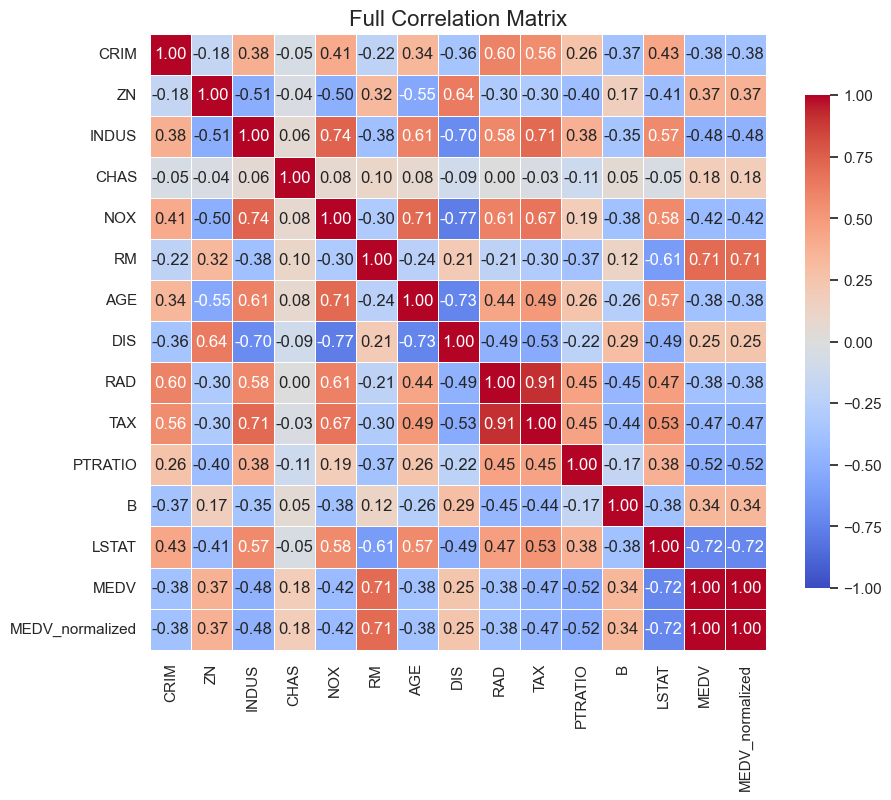

In [19]:
# Calculate the correlation
corr = df.corr()

# Create a mask of zeros (np.zeros_like)
# Since they are all zeros (False), all cells will be displayed
mask = np.zeros_like(corr, dtype=bool)

# Configure the plot aesthetics
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Draw the full heatmap
sns.heatmap(
    corr, 
    mask=mask,               # Apply the zero mask (shows all)
    cmap='coolwarm',         # The color map you chose
    vmax=1, vmin=-1,         # Full correlation range
    center=0,                # Neutral color is at 0
    square=True,             # Square cells
    linewidths=.5,           # Lines between cells
    annot=True,              # Show numeric values
    fmt=".2f",               # Format with 2 decimal places
    cbar_kws={"shrink": .8}  # Adjust size of the side bar
)

plt.title('Full Correlation Matrix', fontsize=16)
plt.show()

Strong: ['LSTAT', 'RM']
Weak: ['DIS', 'B']


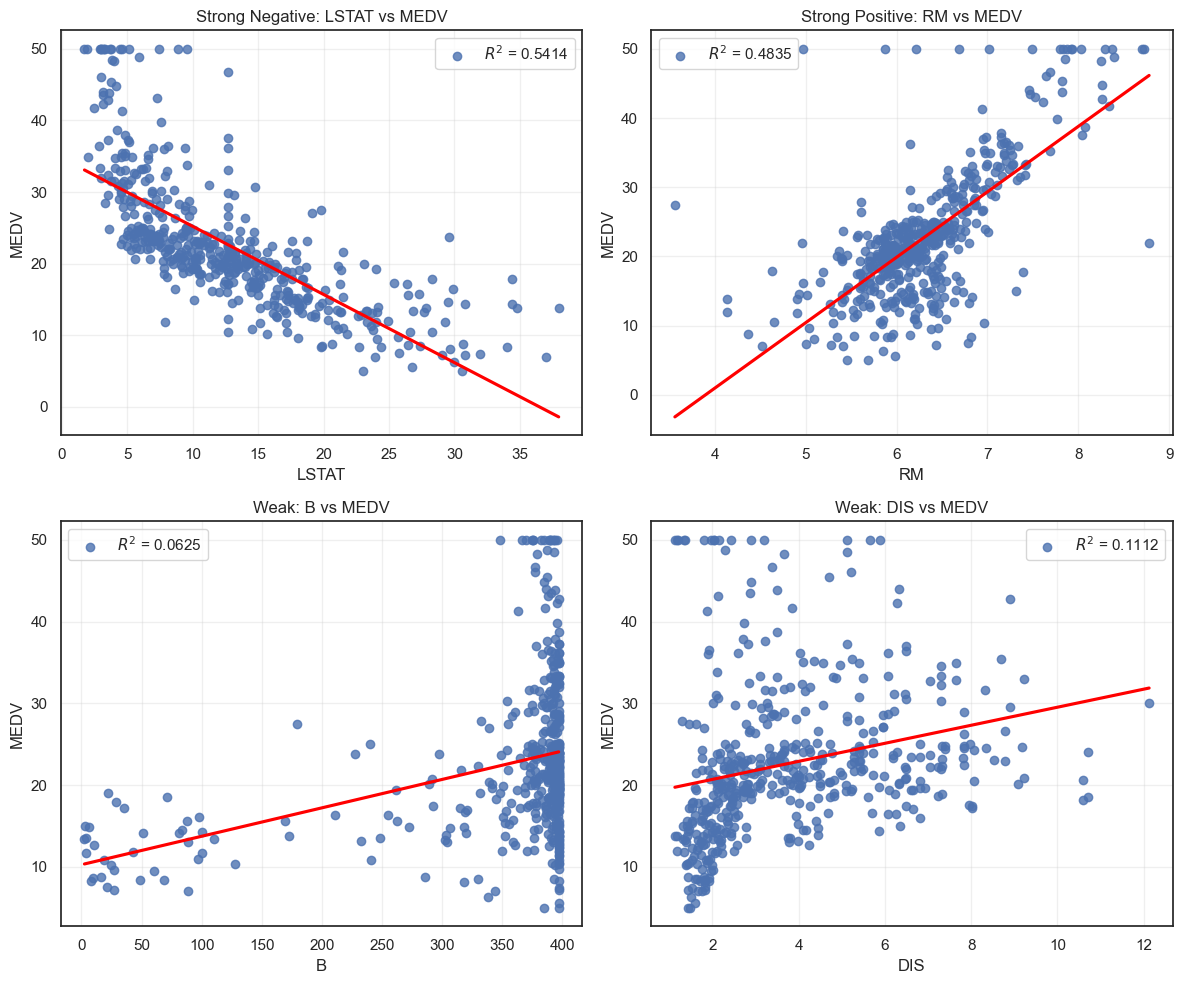

In [20]:
# Calculate the correlations between the numerical features and the response variable
correlations = boston[num_feats + [response]].corr()[response].drop(response)

# Identify the two features with the strongest and weaknest correlations
strong = correlations.abs().nlargest(2).index.tolist()
weak = correlations.abs().nsmallest(2).index.tolist()

# Print the identified features
print(f"Strong: {strong}")
print(f"Weak: {weak}")

# Create the subplots for the identified features
plt.figure(figsize=(12, 10))

# Strong Negative: LSTAT vs MEDV
plt.subplot(2, 2, 1)
sns.regplot(x=df['LSTAT'], y=df['MEDV'], ci=None, line_kws={"color": "red"}, label=f'$R^2$ = {correlations[strong[0]]**2:.4f}')
plt.title("Strong Negative: LSTAT vs MEDV")
plt.legend()
plt.grid(True, alpha = 0.3)

# Strong Positive: RM vs MEDV
plt.subplot(2, 2, 2)
sns.regplot(x=df['RM'], y=df['MEDV'], ci=None, line_kws={"color": "red"}, label=f'$R^2$ = {correlations[strong[1]]**2:.4f}')
plt.title("Strong Positive: RM vs MEDV")
plt.legend()
plt.grid(True, alpha = 0.3)

# Weak: B vs MEDV
plt.subplot(2, 2, 3)
sns.regplot(x=df['B'], y=df['MEDV'], ci=None, line_kws={"color": "red"}, label=f'$R^2$ = {correlations[weak[0]]**2:.4f}')
plt.title("Weak: B vs MEDV")
plt.legend()
plt.grid(True, alpha = 0.3)

# Weak: DIS vs MEDV
plt.subplot(2, 2, 4)
sns.regplot(x=df['DIS'], y=df['MEDV'], ci=None, line_kws={"color": "red"}, label=f'$R^2$ = {correlations[weak[1]]**2:.4f}')
plt.title("Weak: DIS vs MEDV")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

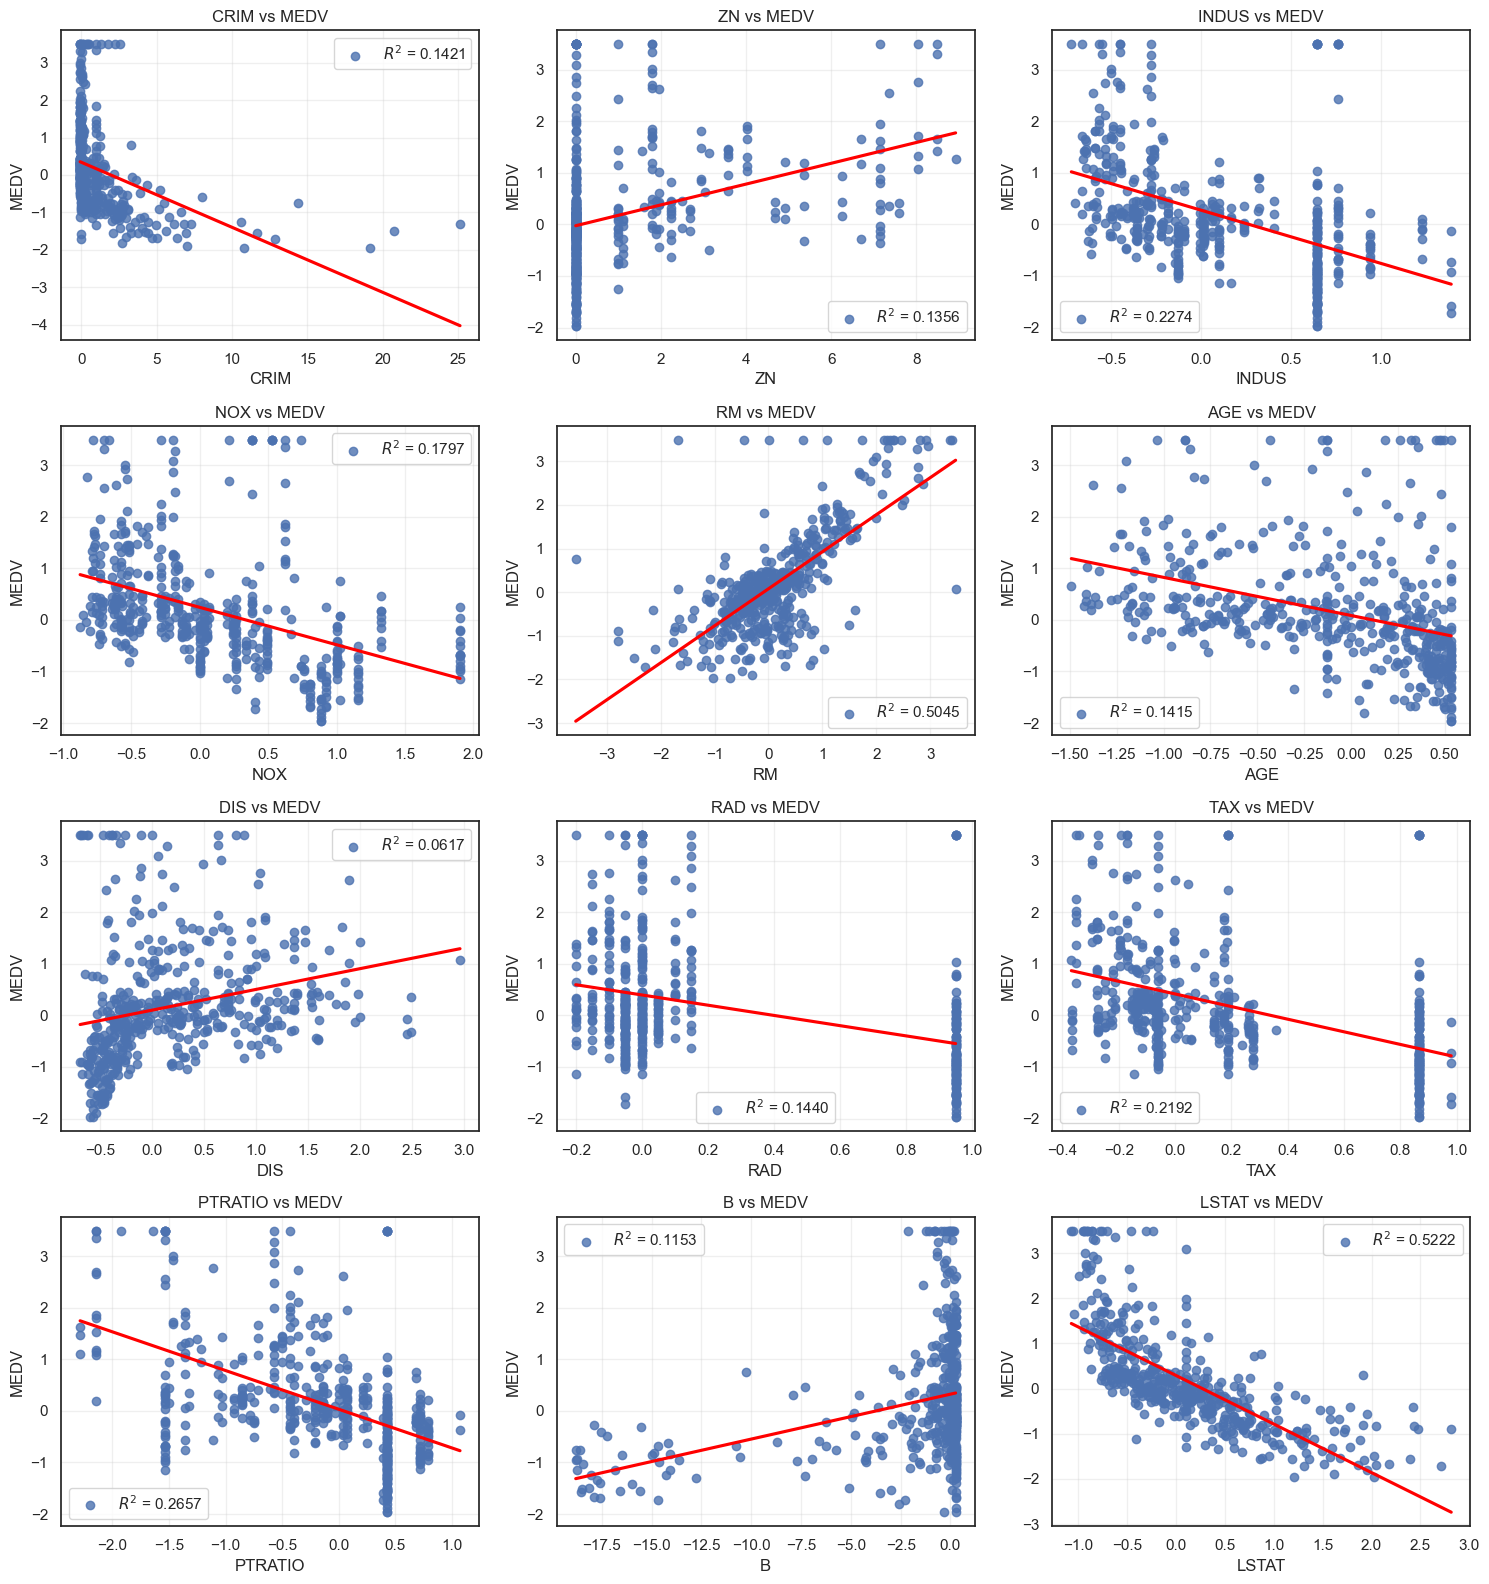

In [21]:
# Copy of the DataFrame
df = df.copy()

# Columns to scale
features_to_scale = num_feats + [response]

# Scaling
scaler = RobustScaler()
df_scaled_array = scaler.fit_transform(df[features_to_scale])
df_normalized = pd.DataFrame(df_scaled_array, columns=features_to_scale, index=df.index)

# Calculate correlations
correlations = df_normalized.corr()[response].drop(response)

# Number of plots
n = len(num_feats)
cols = 3  # number of columns in the figure
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

# Create scatter plots with regression lines for each numerical variable against the response variable
for i, feature in enumerate(num_feats):
    plt.subplot(rows, cols, i + 1)
    
    sns.regplot(
        x=df_normalized[feature],
        y=df_normalized[response],
        ci=None,
        line_kws={"color": "red"},
        label=f'$R^2$ = {correlations[feature]**2:.4f}'
    )
    
    plt.title(f"{feature} vs {response}")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Analysis:**

Looking at the graphs, briefly comment on whether you can see the high or low correlations that you had identified numerically.

Finally, we can use linear correlation to see how much each attribute relates to MEDV. The attributes with the highest R2 values are LSTAT (R2=0.522) and RM (R2=0.505). First, we will analyze why these two are the most significant predictors:

- LSTAT: This attribute indicates the percentage of the population with lower socioeconomic status in a neighborhood. Values near 4.98 indicate wealthier areas, while values around 30 indicate lower-income neighborhoods. Logically, we can deduce that house prices will be higher in affluent neighborhoods where residents have higher acquisition power, compared to areas with lower incomes and lower purchasing power. This results in a strong negative correlation.

- RM: This attribute represents the average number of rooms per house, with most Boston neighborhoods averaging between 5 and 6 rooms. We can safely assume that the more rooms a house has, the larger and more expensive it becomes. As seen in our data, the average is approximately 6.3 rooms per house; as this number increases, we find the most expensive houses in the dataset ranging from 7 to 9 rooms, showing a strong positive correlation.

To conclude with this analysis we will analyze the attributes that least affect MEDV, in other words, those with the lowest correlation.

- B: This variable represents a statistical transform of the proportion of Black residents in the neighborhood. We can observe that as social standards have evolved towards more progressive ideologies where systemic racism is not as prevalent in housing valuation as it once was, it is expected for attribute B to show a lower correlation compared to economic factors. While it still holds some statistical weight in this dataset, it is far from being a primary driver of price like LSTAT or RM.
  
- DIS: This represents the weighted distance to employment centers. As we know, the US is a country with a culture highly centered on car travel and highway accessibility. The cultural habit of driving to work is so deeply ingrained in the US (with extensive highway systems) that moderate distances do not significantly decrease a property's value, making DIS a less relevant factor for MEDV than one might expect in more pedestrian-focused cities.

